# Visuomotor Reaction-Time Analysis

This notebook analyzes reaction time from a BCI2000 `.dat` recording generated by the USB HID visuomotor joystick task.

It is written to work with both:

- **older recordings** that do **not** contain the `Introduction` state
- **newer recordings** that do contain the `Introduction` state

The main behavioral comparison follows the Neumann et al. visuomotor paradigm:

- **Automatic condition**: congruent joystick-to-cursor mapping
- **Controlled condition**: inverted joystick-to-cursor mapping
- **Ordered blocks**: the mapping condition is known in advance
- **Pseudorandom block**: automatic and controlled trials are mixed
- **Reaction-time adaptation**: `Controlled RT - Automatic RT`

Reaction time is already calculated by the BCI2000 task as the interval between target appearance and movement onset and stored in `ReactionTimeMs`.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from BCI2000Tools.FileReader import bcistream

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)


## 1. Select the BCI2000 `.dat` file

In [2]:
# Change this path to the recording you want to analyze.
DAT_PATH = Path(
    r"C:\Users\gabri\Desktop\joystick_test_env\python_da\patient_data\ECOGS001R02.dat"
)

if not DAT_PATH.is_file():
    raise FileNotFoundError(
        f"File not found: {DAT_PATH}\n"
        "Edit DAT_PATH above so it points to the correct BCI2000 .dat file."
    )

print(f"Using: {DAT_PATH.resolve()}")


Using: C:\Users\gabri\Desktop\joystick_test_env\python_da\patient_data\ECOGS001R02.dat


## 2. Open the file and determine recording compatibility

The analysis requires the core experimental states listed below.

`Introduction` is treated as **optional** because older recordings were created before that state was added.

When `Introduction` is absent, experimental trials are identified using:

- `TaskTrial > 0`
- `TaskBlock > 0`

This is compatible with the current task structure, where experimental trials use one-based block and trial numbers.


In [3]:
stream = bcistream(str(DAT_PATH))
params = stream.params

required_states = [
    "TaskCondition",
    "TaskBlockType",
    "TaskBlock",
    "TaskTrial",
    "TargetHit",
    "ReactionTimeMs",
    "MovementTimeMs",
    "TotalTimeMs",
    "TargetAngle",
]

optional_states = [
    "Introduction",
]

missing_states = [
    name for name in required_states
    if name not in stream.statedefs
]

available_optional_states = [
    name for name in optional_states
    if name in stream.statedefs
]

states_to_decode = required_states + available_optional_states

app_chain = params.get("ApplicationFilterChain", [])
app_modules = [row[0] for row in app_chain] if app_chain else []

print(f"File: {DAT_PATH.resolve()}")
print(
    f"Recording: {stream.nchan} channels, "
    f"{stream.samples()} samples @ {stream.samplingfreq_hz} Hz"
)
print(
    "Application modules: "
    + (", ".join(app_modules) if app_modules else "(none)")
)
print()

if missing_states:
    raise KeyError(
        "This file is missing required task states:\n  "
        + "\n  ".join(missing_states)
    )

print("All required reaction-time analysis states are present.")

if "Introduction" in stream.statedefs:
    compatibility_mode = "new"
    print("Recording format: newer task version")
    print("Introduction state found and will be used to exclude tutorial/practice.")
else:
    compatibility_mode = "legacy"
    print("Recording format: older task version")
    print(
        "Introduction state not found. Experimental trials will instead "
        "be identified using TaskTrial > 0 and TaskBlock > 0."
    )


File: C:\Users\gabri\Desktop\joystick_test_env\python_da\patient_data\ECOGS001R02.dat
Recording: 256 channels, 1255100 samples @ 2000.0 Hz
Application modules: USBHIDJoystickTask, KeystrokeFilter, GazeMonitorFilter, CereStim, gEstimFilter

All required reaction-time analysis states are present.
Recording format: older task version
Introduction state not found. Experimental trials will instead be identified using TaskTrial > 0 and TaskBlock > 0.


## 3. Decode the required states

In [4]:
_, states = stream.decode(
    nsamp="all",
    states=states_to_decode,
)

state_arrays = {
    name: np.asarray(states[name]).ravel()
    for name in states_to_decode
}

print(f"Decoded {len(state_arrays)} states.")
print(f"Samples per state: {len(next(iter(state_arrays.values()))):,}")


Decoded 9 states.
Samples per state: 1,255,100


## 4. Inspect state behavior

This table is a quick diagnostic showing the range, number of unique values, and number of transitions for each decoded state.


In [5]:
state_summary = pd.DataFrame(
    {
        name: {
            "min": arr.min(),
            "max": arr.max(),
            "n_unique": np.unique(arr).size,
            "n_changes": int(np.count_nonzero(np.diff(arr))),
        }
        for name, arr in state_arrays.items()
    }
).T

state_summary


,min,max,n_unique,n_changes
TaskCondition,0,1,2,39
TaskBlockType,0,2,3,2
TaskBlock,0,3,4,3
TaskTrial,0,80,81,80
TargetHit,0,1,2,160
ReactionTimeMs,0,5151,41,159
MovementTimeMs,0,10403,70,159
TotalTimeMs,0,10804,71,159
TargetAngle,0,3570,78,79


## 5. Identify completed experimental trials

A completed trial is identified at the sample where `TargetHit == 1`.

That is the same moment at which the task stores the completed trial's:

- reaction time
- movement time
- total time
- condition
- block
- trial number
- target angle

The notebook therefore extracts **one row per successful trial**, rather than treating every BCI2000 sample as an observation.


In [6]:
if "Introduction" in state_arrays:
    experimental_mask = state_arrays["Introduction"] == 0
else:
    experimental_mask = (
        (state_arrays["TaskTrial"] > 0)
        & (state_arrays["TaskBlock"] > 0)
    )

hit_mask = experimental_mask & (state_arrays["TargetHit"] == 1)
hit_indices = np.flatnonzero(hit_mask)

print(f"TargetHit samples retained as experimental trials: {len(hit_indices)}")


TargetHit samples retained as experimental trials: 8000


## 6. Build a trial-level DataFrame

In [7]:
condition_labels = {
    0: "Automatic",
    1: "Controlled",
}

block_type_labels = {
    0: "Ordered automatic",
    1: "Ordered controlled",
    2: "Pseudorandom",
}

trials = pd.DataFrame(
    {
        "sample_index": hit_indices,
        "time_s": hit_indices / float(stream.samplingfreq_hz),
        "trial": state_arrays["TaskTrial"][hit_indices].astype(int),
        "block": state_arrays["TaskBlock"][hit_indices].astype(int),
        "condition_code": state_arrays["TaskCondition"][hit_indices].astype(int),
        "block_type_code": state_arrays["TaskBlockType"][hit_indices].astype(int),
        "target_angle_tenths_deg": state_arrays["TargetAngle"][hit_indices].astype(int),
        "reaction_time_ms": state_arrays["ReactionTimeMs"][hit_indices].astype(float),
        "movement_time_ms": state_arrays["MovementTimeMs"][hit_indices].astype(float),
        "total_time_ms": state_arrays["TotalTimeMs"][hit_indices].astype(float),
    }
)

trials["condition"] = trials["condition_code"].map(condition_labels)
trials["block_type"] = trials["block_type_code"].map(block_type_labels)
trials["target_angle_deg"] = trials["target_angle_tenths_deg"] / 10.0

# The task uses 0 when movement onset was not successfully detected.
trials["reaction_time_ms"] = trials["reaction_time_ms"].replace(0, np.nan)
trials["movement_time_ms"] = trials["movement_time_ms"].replace(0, np.nan)

trials["context"] = np.where(
    trials["block_type_code"] == 2,
    "Pseudorandom",
    "Ordered",
)

print(f"Completed experimental trials found: {len(trials)}")
trials.head(10)


Completed experimental trials found: 8000


,sample_index,time_s,trial,block,condition_code,block_type_code,target_angle_tenths_deg,reaction_time_ms,movement_time_ms,total_time_ms,condition,block_type,target_angle_deg,context
0,28400,14.2000,1,1,0,0,1276,949.0,1900.0,2849.0,Automatic,Ordered automatic,127.6,Ordered
1,28401,14.2005,1,1,0,0,1276,949.0,1900.0,2849.0,Automatic,Ordered automatic,127.6,Ordered
2,28402,14.2010,1,1,0,0,1276,949.0,1900.0,2849.0,Automatic,Ordered automatic,127.6,Ordered
3,28403,14.2015,1,1,0,0,1276,949.0,1900.0,2849.0,Automatic,Ordered automatic,127.6,Ordered
4,28404,14.2020,1,1,0,0,1276,949.0,1900.0,2849.0,Automatic,Ordered automatic,127.6,Ordered
5,28405,14.2025,1,1,0,0,1276,949.0,1900.0,2849.0,Automatic,Ordered automatic,127.6,Ordered
6,28406,14.2030,1,1,0,0,1276,949.0,1900.0,2849.0,Automatic,Ordered automatic,127.6,Ordered
7,28407,14.2035,1,1,0,0,1276,949.0,1900.0,2849.0,Automatic,Ordered automatic,127.6,Ordered
8,28408,14.2040,1,1,0,0,1276,949.0,1900.0,2849.0,Automatic,Ordered automatic,127.6,Ordered
9,28409,14.2045,1,1,0,0,1276,949.0,1900.0,2849.0,Automatic,Ordered automatic,127.6,Ordered


## 7. Trial extraction quality checks

In [8]:
quality_summary = pd.Series(
    {
        "completed_trials": len(trials),
        "unique_trial_numbers": trials["trial"].nunique(),
        "automatic_trials": int((trials["condition"] == "Automatic").sum()),
        "controlled_trials": int((trials["condition"] == "Controlled").sum()),
        "ordered_trials": int((trials["context"] == "Ordered").sum()),
        "pseudorandom_trials": int((trials["context"] == "Pseudorandom").sum()),
        "missing_reaction_times": int(trials["reaction_time_ms"].isna().sum()),
        "missing_movement_times": int(trials["movement_time_ms"].isna().sum()),
    },
    name="count",
)

display(quality_summary.to_frame())

duplicate_trials = trials["trial"].duplicated(keep=False)

if duplicate_trials.any():
    print("Warning: duplicate TaskTrial values were found.")
    display(trials.loc[duplicate_trials].sort_values("trial"))
else:
    print("No duplicate completed trial numbers found.")


,count
completed_trials,8000
unique_trial_numbers,80
automatic_trials,4000
controlled_trials,4000
ordered_trials,2000
pseudorandom_trials,6000
missing_reaction_times,0
missing_movement_times,0


,sample_index,time_s,trial,block,condition_code,block_type_code,target_angle_tenths_deg,reaction_time_ms,movement_time_ms,total_time_ms,condition,block_type,target_angle_deg,context
96,28496,14.2480,1,1,0,0,1276,949.0,1900.0,2849.0,Automatic,Ordered automatic,127.6,Ordered
97,28497,14.2485,1,1,0,0,1276,949.0,1900.0,2849.0,Automatic,Ordered automatic,127.6,Ordered
98,28498,14.2490,1,1,0,0,1276,949.0,1900.0,2849.0,Automatic,Ordered automatic,127.6,Ordered
99,28499,14.2495,1,1,0,0,1276,949.0,1900.0,2849.0,Automatic,Ordered automatic,127.6,Ordered
24,28424,14.2120,1,1,0,0,1276,949.0,1900.0,2849.0,Automatic,Ordered automatic,127.6,Ordered
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7969,1254069,627.0345,80,3,1,2,600,999.0,9051.0,10049.0,Controlled,Pseudorandom,60.0,Pseudorandom
7998,1254098,627.0490,80,3,1,2,600,999.0,9051.0,10049.0,Controlled,Pseudorandom,60.0,Pseudorandom
7999,1254099,627.0495,80,3,1,2,600,999.0,9051.0,10049.0,Controlled,Pseudorandom,60.0,Pseudorandom
7968,1254068,627.0340,80,3,1,2,600,999.0,9051.0,10049.0,Controlled,Pseudorandom,60.0,Pseudorandom


## 8. Reaction time by condition

The primary comparison is automatic versus controlled reaction time.

The controlled condition requires the participant to suppress the intuitive congruent response and use the inverted mapping instead.


In [9]:
rt_by_condition = (
    trials.groupby("condition", observed=True)["reaction_time_ms"]
    .agg(["count", "mean", "median", "std", "sem"])
    .rename(
        columns={
            "count": "n_trials",
            "mean": "mean_rt_ms",
            "median": "median_rt_ms",
            "std": "sd_rt_ms",
            "sem": "sem_rt_ms",
        }
    )
)

rt_by_condition


,n_trials,mean_rt_ms,median_rt_ms,sd_rt_ms,sem_rt_ms
condition,,,,,
Automatic,4000,728.70,698.5,246.444403,3.896628
Controlled,4000,839.65,698.5,723.961814,11.446841


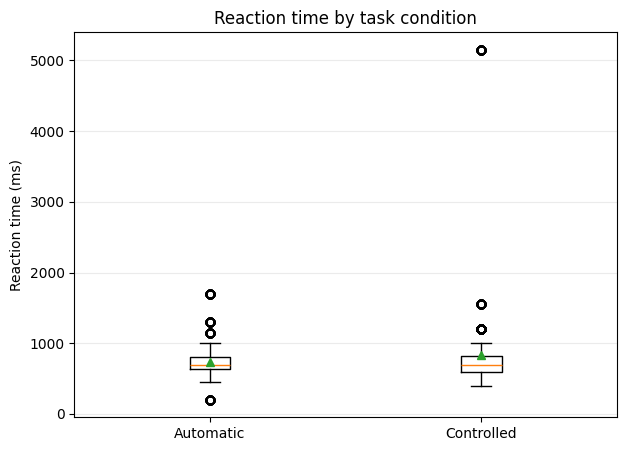

In [10]:
automatic_rt = trials.loc[
    trials["condition"] == "Automatic",
    "reaction_time_ms"
].dropna()

controlled_rt = trials.loc[
    trials["condition"] == "Controlled",
    "reaction_time_ms"
].dropna()

fig, ax = plt.subplots(figsize=(7, 5))

ax.boxplot(
    [automatic_rt, controlled_rt],
    tick_labels=["Automatic", "Controlled"],
    showmeans=True,
)

ax.set_ylabel("Reaction time (ms)")
ax.set_title("Reaction time by task condition")
ax.grid(axis="y", alpha=0.25)

plt.show()


## 9. Reaction time by ordered versus pseudorandom context

Ordered blocks tell the participant which mapping condition is active before the block begins.

The pseudorandom block mixes automatic and controlled trials, increasing uncertainty about the required mapping from trial to trial.


In [11]:
rt_by_context_condition = (
    trials.groupby(
        ["context", "condition"],
        observed=True
    )["reaction_time_ms"]
    .agg(["count", "mean", "median", "std", "sem"])
    .rename(
        columns={
            "count": "n_trials",
            "mean": "mean_rt_ms",
            "median": "median_rt_ms",
            "std": "sd_rt_ms",
            "sem": "sem_rt_ms",
        }
    )
)

rt_by_context_condition


n_trials  mean_rt_ms  median_rt_ms    sd_rt_ms  sem_rt_ms
context      condition                                                            
Ordered      Automatic       1000  564.800000         524.5  189.835185   6.003116
             Controlled      1000  584.500000         599.5   83.844379   2.651392
Pseudorandom Automatic       3000  783.333333         700.0  238.828185   4.360386
             Controlled      3000  924.700000         750.0  817.068220  14.917557

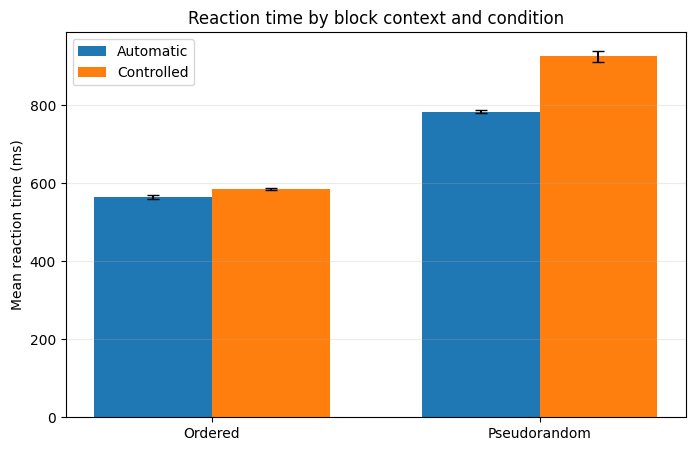

In [12]:
summary_plot = (
    trials.groupby(
        ["context", "condition"],
        observed=True
    )["reaction_time_ms"]
    .agg(["mean", "sem"])
    .reset_index()
)

contexts = ["Ordered", "Pseudorandom"]
conditions = ["Automatic", "Controlled"]

available_contexts = [
    context for context in contexts
    if context in summary_plot["context"].unique()
]

x = np.arange(len(available_contexts))
width = 0.36

fig, ax = plt.subplots(figsize=(8, 5))

for i, condition in enumerate(conditions):
    sub = (
        summary_plot[summary_plot["condition"] == condition]
        .set_index("context")
        .reindex(available_contexts)
    )

    offset = (i - 0.5) * width

    ax.bar(
        x + offset,
        sub["mean"],
        width,
        yerr=sub["sem"],
        capsize=4,
        label=condition,
    )

ax.set_xticks(x, available_contexts)
ax.set_ylabel("Mean reaction time (ms)")
ax.set_title("Reaction time by block context and condition")
ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.show()


## 10. Reaction-time adaptation

Following the behavioral comparison in the reference paper:

`Reaction-time adaptation = mean Controlled RT - mean Automatic RT`

A positive value means the participant takes longer to initiate movement during the controlled inverted-mapping condition.


In [13]:
adaptation_rows = []

for context, df_context in trials.groupby("context", observed=True):
    means = df_context.groupby(
        "condition",
        observed=True
    )["reaction_time_ms"].mean()

    automatic = means.get("Automatic", np.nan)
    controlled = means.get("Controlled", np.nan)

    adaptation_rows.append(
        {
            "context": context,
            "automatic_mean_rt_ms": automatic,
            "controlled_mean_rt_ms": controlled,
            "controlled_minus_automatic_ms": controlled - automatic,
        }
    )

rt_adaptation = pd.DataFrame(adaptation_rows).set_index("context")
rt_adaptation


,automatic_mean_rt_ms,controlled_mean_rt_ms,controlled_minus_automatic_ms
context,,,
Ordered,564.800000,584.5,19.700000
Pseudorandom,783.333333,924.7,141.366667


## 11. Overall automatic-to-controlled reaction-time cost

This collapses across all experimental blocks.


In [14]:
overall_means = trials.groupby(
    "condition",
    observed=True
)["reaction_time_ms"].mean()

automatic_mean = overall_means.get("Automatic", np.nan)
controlled_mean = overall_means.get("Controlled", np.nan)

overall_rt_cost = controlled_mean - automatic_mean

print(f"Automatic mean RT:  {automatic_mean:.1f} ms")
print(f"Controlled mean RT: {controlled_mean:.1f} ms")
print(
    "Controlled - Automatic RT: "
    f"{overall_rt_cost:.1f} ms"
)


Automatic mean RT:  728.7 ms
Controlled mean RT: 839.6 ms
Controlled - Automatic RT: 110.9 ms


## 12. Trial-by-trial reaction time

This plot can reveal:

- learning
- fatigue
- outliers
- condition switches
- changes at block boundaries


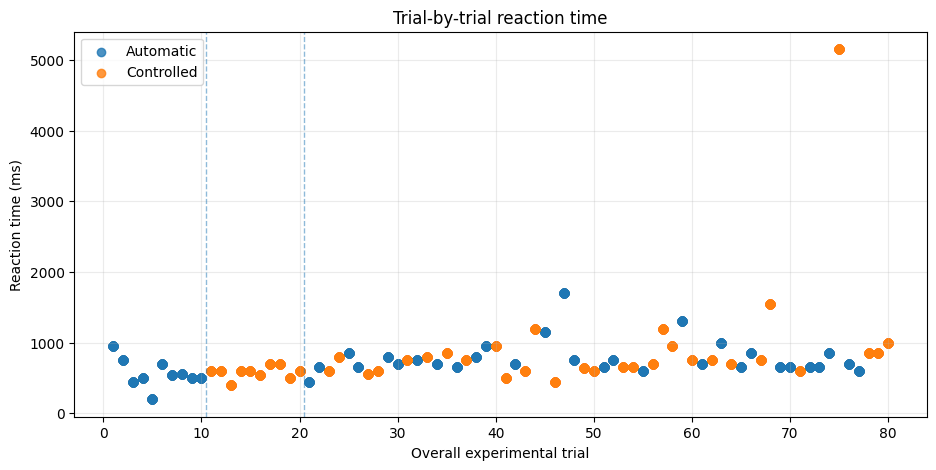

In [15]:
fig, ax = plt.subplots(figsize=(11, 5))

for condition in ["Automatic", "Controlled"]:
    sub = trials[trials["condition"] == condition]

    ax.scatter(
        sub["trial"],
        sub["reaction_time_ms"],
        label=condition,
        alpha=0.8,
    )

block_starts = (
    trials.groupby("block", observed=True)["trial"]
    .min()
    .sort_values()
)

for trial_start in block_starts.iloc[1:]:
    ax.axvline(
        trial_start - 0.5,
        linestyle="--",
        linewidth=1,
        alpha=0.5,
    )

ax.set_xlabel("Overall experimental trial")
ax.set_ylabel("Reaction time (ms)")
ax.set_title("Trial-by-trial reaction time")
ax.legend()
ax.grid(alpha=0.25)

plt.show()


## 13. Reaction time by target angle

The task stores target direction in `TargetAngle` as tenths of a degree.

This section bins directions into 45-degree bins to check whether reaction time depends strongly on movement direction.


In [16]:
angle_trials = trials.copy()

angle_trials["angle_bin_deg"] = (
    np.round(angle_trials["target_angle_deg"] / 45) * 45
) % 360

angle_summary = (
    angle_trials.groupby(
        ["condition", "angle_bin_deg"],
        observed=True
    )["reaction_time_ms"]
    .agg(["count", "mean", "median", "std"])
    .rename(
        columns={
            "count": "n_trials",
            "mean": "mean_rt_ms",
            "median": "median_rt_ms",
            "std": "sd_rt_ms",
        }
    )
)

angle_summary


n_trials   mean_rt_ms  median_rt_ms     sd_rt_ms
condition  angle_bin_deg                                                  
Automatic  0.0                 300   817.000000         801.0   102.858802
           45.0                200  1074.500000        1074.5   226.065873
           90.0                400   800.250000         750.5   118.584752
           135.0               900   655.222222         650.0   151.506912
           180.0               500   699.800000         701.0    70.785459
           225.0              1200   750.166667         675.0   358.736043
           315.0               500   589.800000         649.0    73.806876
Controlled 0.0                 600   874.833333         749.5   327.409734
           45.0                800   775.000000         750.0   246.071003
           90.0                600   650.166667         600.5   115.712811
           135.0               800   630.500000         625.0    86.345640
           180.0               100   750.000000         750.0     0.000000
           225.0               300  2350.666667        1200.0  1993.912195
           270.0               300   613.666667         545.0   133.490153
           315.0               500   709.800000         699.0   102.102938

## 14. Movement time and total performance time

The paper distinguishes reaction time from movement execution.

These summaries are included so reaction-time effects can be interpreted separately from slower or faster movement after movement onset.


In [17]:
timing_summary = (
    trials.groupby("condition", observed=True)[
        [
            "reaction_time_ms",
            "movement_time_ms",
            "total_time_ms",
        ]
    ]
    .agg(["count", "mean", "median", "std"])
)

timing_summary


reaction_time_ms                            movement_time_ms                                total_time_ms                    \
                      count    mean median         std            count      mean  median          std         count      mean  median   
condition                                                                                                                                
Automatic              4000  728.70  698.5  246.444403             4000  1458.800  1275.0   896.072121          4000  2187.475  2000.0   
Controlled             4000  839.65  698.5  723.961814             4000  2687.875  2275.0  1877.463309          4000  3527.400  2951.0   

                         
                    std  
condition                
Automatic   1008.209636  
Controlled  2058.735495

## 15. Participant-level summary

This creates one row containing the main values that can later be combined across multiple participants.

For group analysis, each participant should contribute one summary row rather than treating all trials across all participants as independent observations.


In [18]:
overall_means = trials.groupby(
    "condition",
    observed=True
)["reaction_time_ms"].mean()

participant_summary = {
    "file": DAT_PATH.name,
    "recording_format": compatibility_mode,
    "n_completed_trials": len(trials),
    "automatic_mean_rt_ms": overall_means.get("Automatic", np.nan),
    "controlled_mean_rt_ms": overall_means.get("Controlled", np.nan),
}

participant_summary["controlled_minus_automatic_ms"] = (
    participant_summary["controlled_mean_rt_ms"]
    - participant_summary["automatic_mean_rt_ms"]
)

for context in ["Ordered", "Pseudorandom"]:
    sub = trials[trials["context"] == context]

    means = sub.groupby(
        "condition",
        observed=True
    )["reaction_time_ms"].mean()

    key = context.lower()

    participant_summary[
        f"{key}_automatic_mean_rt_ms"
    ] = means.get("Automatic", np.nan)

    participant_summary[
        f"{key}_controlled_mean_rt_ms"
    ] = means.get("Controlled", np.nan)

    participant_summary[
        f"{key}_controlled_minus_automatic_ms"
    ] = (
        means.get("Controlled", np.nan)
        - means.get("Automatic", np.nan)
    )

participant_summary_df = pd.DataFrame([participant_summary])

participant_summary_df.T


,0
file,ECOGS001R02.dat
recording_format,legacy
n_completed_trials,8000
automatic_mean_rt_ms,728.7
controlled_mean_rt_ms,839.65
controlled_minus_automatic_ms,110.95
ordered_automatic_mean_rt_ms,564.8
ordered_controlled_mean_rt_ms,584.5
ordered_controlled_minus_automatic_ms,19.7
pseudorandom_automatic_mean_rt_ms,783.333333


## 16. Save extracted trial data and participant summary

These files are useful for later group-level analysis.


In [19]:
output_dir = DAT_PATH.parent / "reaction_time_analysis"
output_dir.mkdir(exist_ok=True)

trial_output = output_dir / f"{DAT_PATH.stem}_trials.csv"
summary_output = output_dir / f"{DAT_PATH.stem}_summary.csv"

trials.to_csv(trial_output, index=False)
participant_summary_df.to_csv(summary_output, index=False)

print(f"Saved trial table: {trial_output}")
print(f"Saved participant summary: {summary_output}")


Saved trial table: C:\Users\gabri\Desktop\joystick_test_env\python_da\patient_data\reaction_time_analysis\ECOGS001R02_trials.csv
Saved participant summary: C:\Users\gabri\Desktop\joystick_test_env\python_da\patient_data\reaction_time_analysis\ECOGS001R02_summary.csv


# Interpretation

The central reaction-time measure is:

`Controlled RT - Automatic RT`

A larger positive value indicates a larger reaction-time cost for the inverted controlled mapping.

The reference paper interprets the longer reaction time in the controlled condition as increased cognitive/inhibitory demand during movement preparation.

The ordered and pseudorandom conditions should also be considered separately because the participant knows the active mapping in advance during ordered blocks but not during trial-by-trial pseudorandom presentation.

For a **single participant**, focus on:

1. the automatic and controlled mean/median RTs
2. the controlled-minus-automatic difference
3. whether that difference changes between ordered and pseudorandom contexts
4. trial-by-trial outliers or drift
5. whether movement time changes in parallel with reaction time

For a future **group analysis**, combine the participant-level summary rows and use participant-level paired comparisons or a mixed-effects model.
